In [16]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import scale
import anndata

# Load your adata if not already loaded
adata = sc.read_h5ad('MRVI_trained_v2.h5ad')

In [17]:
# Option A: use scVI-normalized layer (recommended — batch-corrected)
X = adata.layers['scvi_normalized']

# Convert sparse to dense if needed
if hasattr(X, 'toarray'):
    X = X.toarray()

# Center and scale (zero mean, unit variance per gene) — same as the example notebook
scaled_mat = scale(X)  # shape: (26437, 5000)

print(scaled_mat.shape)  # should be (26437, 5000)

/Users/siam/anaconda3/envs/picasso_env/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


(26437, 5000)


/Users/siam/anaconda3/envs/picasso_env/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:284: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


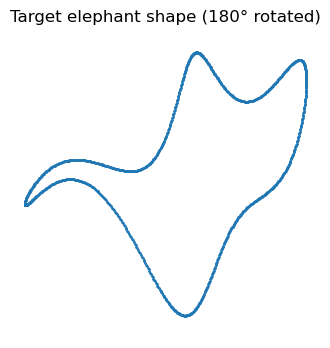

coords shape: (2, 1000)


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ── Elephant Fourier parameters ───────────────────────────────────────────────
p1, p2, p3, p4 = (50 - 30j, 18 + 8j, 12 - 10j, -14 - 60j)
p5 = 40 + 20j

def fourier(t, C):
    f = np.zeros(t.shape)
    A, B = C.real, C.imag
    for k in range(len(C)):
        f = f + A[k]*np.cos(k*t) + B[k]*np.sin(k*t)
    return f

def elephant(t, p1, p2, p3, p4, p5):
    npar = 6
    Cx = np.zeros((npar,), dtype='complex')
    Cy = np.zeros((npar,), dtype='complex')
    Cx[1] = p1.real * 1j
    Cx[2] = p2.real * 1j
    Cx[3] = p3.real
    Cx[5] = p4.real
    Cy[1] = p4.imag + p1.imag * 1j
    Cy[2] = p2.imag * 1j
    Cy[3] = p3.imag * 1j
    x = fourier(t, Cx)
    y = fourier(t, Cy)
    return x, y

# batch_size = number of boundary points = must be ≤ n_cells
batch_size = 1000  # good default; increase if you want a smoother boundary

t = np.linspace(0, 2*np.pi, batch_size)
x, y = elephant(t, p1, p2, p3, p4, p5)

# coords must be shape (2, batch_size)
# 180° rotation: negate y, keep x → flips both axes
coords = np.array([list(-y), list(x)])

# Quick sanity-check plot
plt.figure(figsize=(4, 4))
plt.plot(-y, x, '.', markersize=2)
plt.title('Target elephant shape (180° rotated)')
plt.axis('equal')
plt.axis('off')
plt.show()

print('coords shape:', coords.shape)  # (2, 1000)

In [19]:
import os
print(os.getcwd())
print(os.listdir('./picasso') if os.path.exists('./picasso') else 'no picasso folder here')

/Users/siam/Downloads/test/picasso-main
no picasso folder here


In [20]:
import sys
sys.path.insert(0, '/Users/siam/Downloads/test/picasso-main')   # path to Picasso.py
from Picasso import Picasso

# ── Model hyperparameters ─────────────────────────────────────────────────────
p = Picasso(
    n_latent  = 2,       # must be 2 for a 2D shape
    n_hidden  = 128,     # hidden layer size
    epochs    = 500,     # 300–500 is usually enough; increase for better fit
    batch_size= batch_size,  # same as elephant boundary points
    lr        = 1e-3,
    weight_decay = 1e-5,
)

# ── Fit ───────────────────────────────────────────────────────────────────────
# frac: weight of shape-fit loss vs reconstruction loss
#   0.0  → pure autoencoder (no shape constraint)
#   0.15 → gentle elephant shaping (recommended starting point)
#   0.5+ → stronger shape constraint, may distort biology
losses, latent = p.fit(
    scaled_mat,
    coords,
    frac      = 0.20,
    silent    = False,       # set True to suppress per-epoch printing
    ret_loss  = True,
    print_interval = 50,
)

print('Latent shape:', latent.shape)  # (26437, 2)

====> Epoch: 0 Average loss: 13.6269
====> Epoch: 50 Average loss: 2.4627
====> Epoch: 100 Average loss: 2.4490
====> Epoch: 150 Average loss: 2.3923
====> Epoch: 200 Average loss: 2.3495
====> Epoch: 250 Average loss: 2.3841
====> Epoch: 300 Average loss: 2.3768
====> Epoch: 350 Average loss: 2.3849
====> Epoch: 400 Average loss: 2.3782
====> Epoch: 450 Average loss: 2.3219
Latent shape: (26437, 2)


In [21]:

# Store in obsm just like a normal UMAP embedding
adata.obsm['X_picasso_180flipped_elephant'] = latent

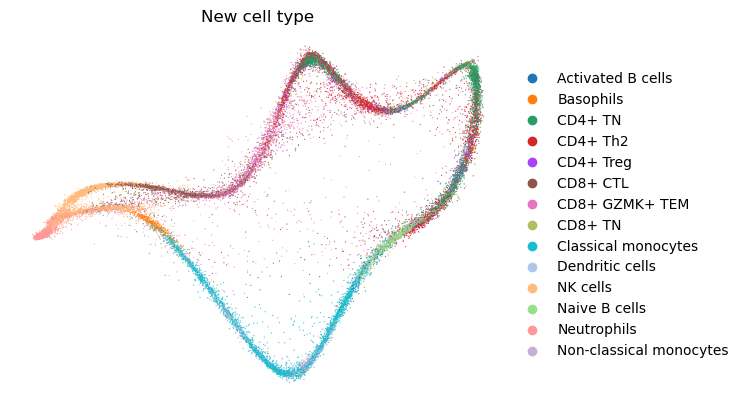

In [23]:
sc.pl.embedding(
    adata,
    basis='picasso_180flipped_elephant',   # scanpy strips 'X_' prefix automatically
    color=['new_cell_type'],
    size=3,
    alpha=0.9,
    frameon=False,
    title=['New cell type'],
)

In [24]:
# Define mapping from detailed cell types to broader categories
cell_type_mapping = {
    # CD4 T cell subsets
    'CD4+ TN': 'CD4 T cell',
    'CD4+ Th2': 'CD4 T cell',
    'CD4+ Treg': 'CD4 T cell',
    
    # CD8 T cell subsets
    'CD8+ CTL': 'CD8 T cell',
    'CD8+ GZMK+ TEM': 'CD8 T cell',
    'CD8+ TN': 'CD8 T cell',
    
    # B cell subsets
    'Activated B cells': 'B cell',
    'Naive B cells': 'B cell',
    
    # Monocyte subsets
    'Classical monocytes': 'Monocyte',
    'Non-classical monocytes': 'Monocyte',
}

# Create new column with simplified cell types (or overwrite existing)
adata.obs['new_cell_type_simplified'] = adata.obs['new_cell_type'].map(
    lambda x: cell_type_mapping.get(x, x)
)

# Verify the unique cell types after grouping
print("Original cell types:", adata.obs['new_cell_type'].unique())
print("\nSimplified cell types:", adata.obs['new_cell_type_simplified'].unique())

Original cell types: ['CD8+ GZMK+ TEM', 'Classical monocytes', 'CD4+ TN', 'CD4+ Treg', 'NK cells', ..., 'Naive B cells', 'CD8+ TN', 'Activated B cells', 'Basophils', 'Dendritic cells']
Length: 14
Categories (14, object): ['Activated B cells', 'Basophils', 'CD4+ TN', 'CD4+ Th2', ..., 'NK cells', 'Naive B cells', 'Neutrophils', 'Non-classical monocytes']

Simplified cell types: ['CD8 T cell' 'Monocyte' 'CD4 T cell' 'NK cells' 'Neutrophils' 'B cell'
 'Basophils' 'Dendritic cells']


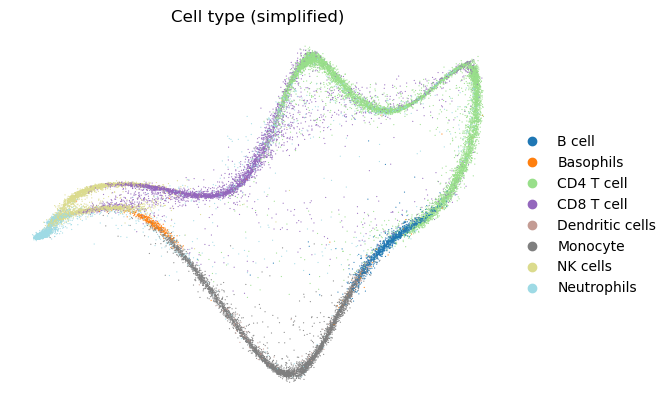

In [25]:
sc.pl.embedding(
    adata,
    basis='picasso_180flipped_elephant',
    color='new_cell_type_simplified',  # use simplified labels
    size=3,
    alpha=0.9,
    frameon=False,
    title='Cell type (simplified)',
    save= "cell_type_simplified_v5.pdf",
    palette="tab20",
)

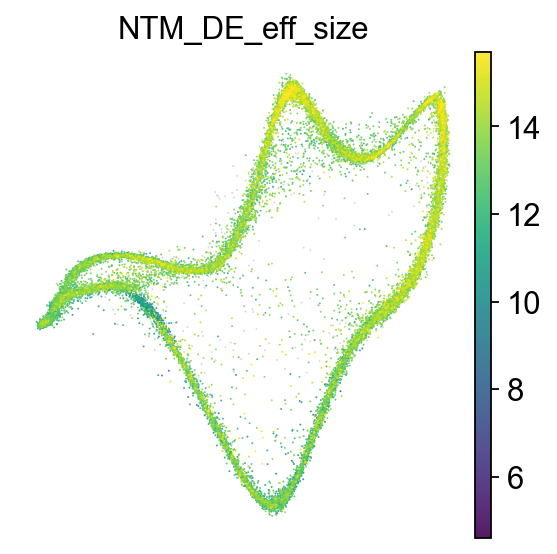

In [28]:
sc.settings.set_figure_params(dpi_save=300)
# sc.pl.umap(
#     adata,
#     color=["NTM_DE_eff_size"],
#     frameon=False,
#     ncols=2,
#     vmax=1,
#     cmap="viridis",
# )

sc.pl.embedding(
    adata,
    basis='picasso_180flipped_elephant',
    color='NTM_DE_eff_size',
    size=3,
    alpha=0.9,
    frameon=False,
    title='NTM_DE_eff_size',
    vmax='p99',
    cmap='viridis',
    save='NTM_DE_eff_size_v6.pdf'
)

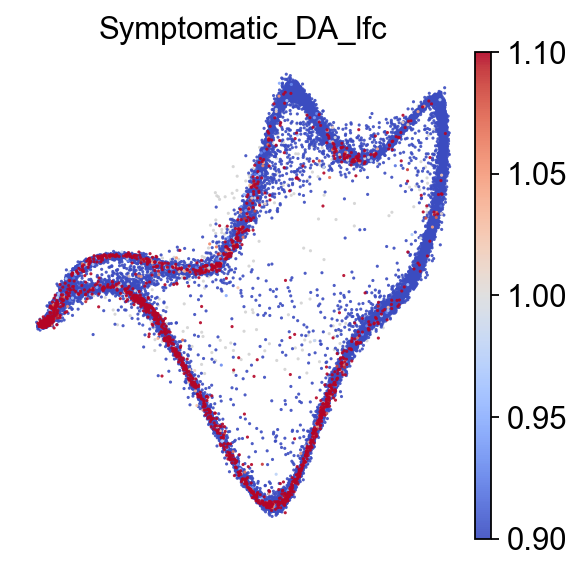

In [29]:
sc.pl.embedding(
    adata,
    basis='picasso_180flipped_elephant',
    color="Symptomatic_DA_lfc",
    frameon=False,
    title='Symptomatic_DA_lfc',
    size=8,
    alpha=0.9,
    vmin = 1,
    vmax=1,
    cmap="coolwarm",
    save='Symptomatic_DA_lfc_v7.pdf'
)

In [30]:
adata.write_h5ad("adata_picasso180flipped_elephant.h5ad")